### 1. Importing the necessary libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier


### 2. Loading Dataset 

### Dataset Note

The dataset used in this analysis was provided as part of the assignment.  
To run this notebook, please place the provided CSV file (`Fraud (2).csv`) in the same directory as this notebook.


In [4]:
df=pd.read_csv("Fraud (2).csv")

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### 3. Basic dataset overview

In [7]:
df.shape

(6362620, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


### 4. Data Cleaning

#### Missing Values

In [11]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

### Observation:
#### No missing values are present in the dataset

#### Statistical Summary

In [14]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


### Insights:

##### Transaction amounts and balances are highly skewed

##### Extreme values exist and are retained

##### Fraud ratio is very low (~0.13%)

#### Outlier Treatment

##### Decision:Outliers are not removed because fraudulent transactions often occur at extreme values.

#### Multicollinearity Check

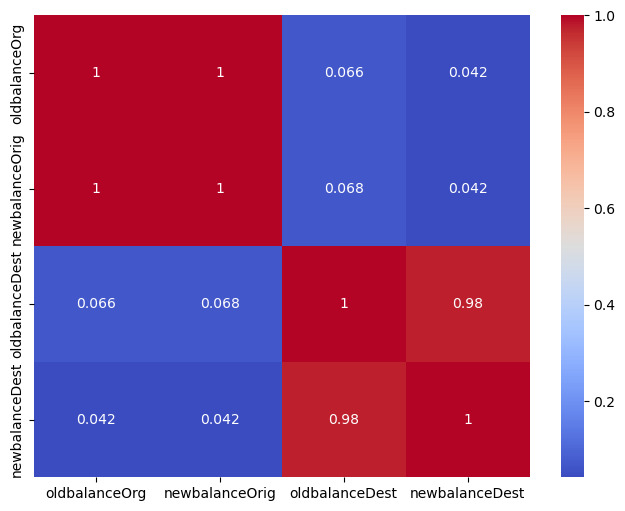

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']].corr(),
            annot=True, cmap='coolwarm')
plt.show()


#### Multicollinearity Analysis

To analyze multicollinearity among numerical variables, a correlation heatmap was generated for balance-related features.

A perfect correlation (≈1.0) is observed between `oldbalanceOrg` and `newbalanceOrig`, and a very high correlation (≈0.98) is observed between `oldbalanceDest` and `newbalanceDest`. This is expected because post-transaction balances are directly derived from pre-transaction balances.

Low correlation values (≈0.04–0.07) are observed between origin and destination account balances, indicating independent transaction behavior.

Although multicollinearity exists among balance variables, these features were retained because tree-based models such as Random Forest and XGBoost are robust to correlated variables. Additionally, balance differences are critical indicators for detecting fraudulent transactions.


### 5. Exploratory Data Analysis (EDA)

#### Class Imbalance

In [22]:
df['isFraud'].value_counts()


isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [23]:
df['isFraud'].value_counts(normalize=True)


isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

#### Fraud by Transaction Type

In [25]:
df.groupby('type')['isFraud'].mean().sort_values(ascending=False)


type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [26]:
df.groupby('type')['isFraud'].mean().sort_values(ascending=False)

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

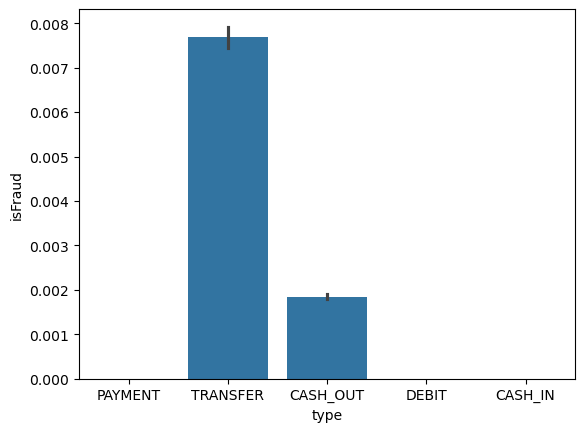

In [27]:
sns.barplot(x='type', y='isFraud', data=df)
plt.show()

Fraud is concentrated in TRANSFER and CASH_OUT transactions, while other transaction types show negligible fraud, 
making transaction type a key predictive feature.

### 6. Feature Engineering

In [30]:
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']


### 7. Feature Selection

#### Drop high-cardinality ID columns

In [33]:
df = df.drop(['nameOrig', 'nameDest'], axis=1)

#### Encode Categorical Variable

In [35]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

### 8. Sampling

In [37]:
fraud = df[df['isFraud'] == 1]
non_fraud = df[df['isFraud'] == 0]

In [38]:
n_fraud = int(0.0013 * 1_000_000)

In [39]:
fraud_sample = fraud.sample(n=n_fraud, random_state=42)
non_fraud_sample = non_fraud.sample(
    n=1_000_000 - n_fraud,
    random_state=42
)

In [40]:
df_sample = pd.concat([fraud_sample, non_fraud_sample])
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_sample['type'] = le.fit_transform(df_sample['type'])

To reduce computation time, a stratified sample of 10 lakh transactions was created by separately sampling fraud 
and non-fraud cases while preserving the original fraud proportion. This approach ensures efficiency without affecting data representativeness.


### 9. Train-Test Split

In [49]:
X = df_sample.drop('isFraud', axis=1)
y = df_sample['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [51]:
df_sample['type'] = df_sample['type'].astype(int)

In [ ]:
df_sample.dtypes

In [55]:
X_train.dtypes

step                   int64
type                   int64
amount               float64
oldbalanceOrg        float64
newbalanceOrig       float64
oldbalanceDest       float64
newbalanceDest       float64
isFlaggedFraud         int64
balance_diff_orig    float64
balance_diff_dest    float64
dtype: object

### 10. Model training

In [57]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

### 11. Model Evaluation

#### Predictions

In [62]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

### Classification Report

In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199740
           1       0.51      0.96      0.67       260

    accuracy                           1.00    200000
   macro avg       0.76      0.98      0.83    200000
weighted avg       1.00      1.00      1.00    200000



#### Confusion Matrix

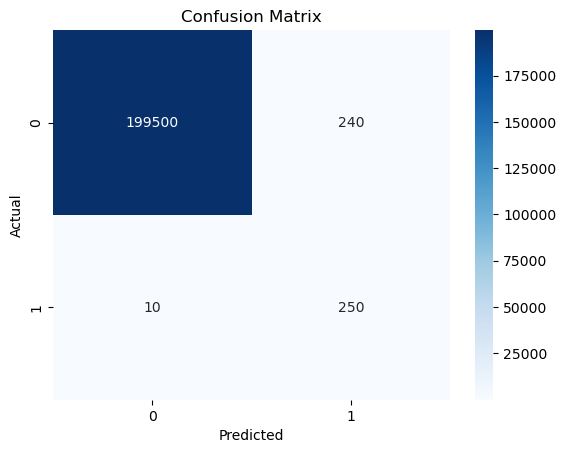

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### ROC-AUC Score

In [71]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_proba)

0.9994616366661275

### 12. Feature Importance

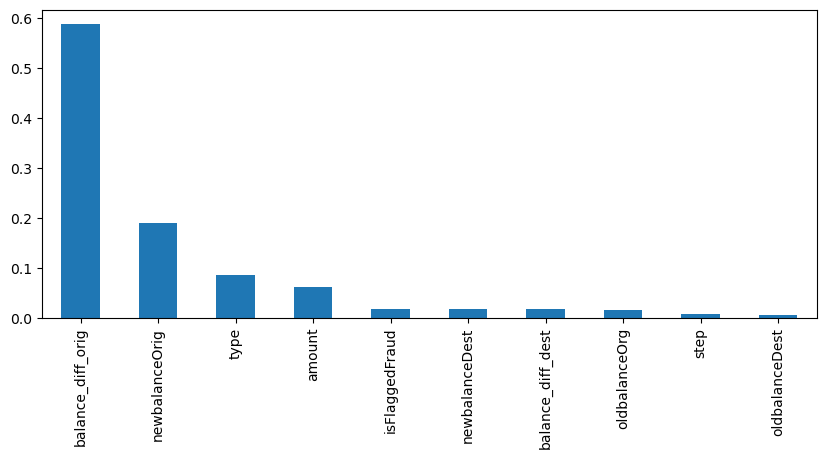

In [74]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.show()

#### Interpretation


The feature importance plot highlights the most influential variables used by the XGBoost model to detect fraudulent transactions.

The most important feature is `balance_diff_orig`, indicating that sudden depletion of funds from the sender’s account is a strong fraud signal.
This is followed by `newbalanceOrig`, which captures abnormal post-transaction balances.

Transaction `type` is also a significant predictor, confirming earlier EDA findings that fraud is concentrated in TRANSFER and CASH_OUT transactions.
Other features such as transaction amount, destination balances, and time step contribute less but still provide supporting context.

Overall, the feature importance aligns well with real-world fraud behavior, where abnormal balance movements 
and risky transaction types are key indicators.


### 13. Key Factors That Predict Fraud

The key factors that predict fraudulent transactions include:
- Sudden and large reduction in the origin account balance (`balance_diff_orig`)
- Abnormal remaining balance after transaction (`newbalanceOrig`)
- High-risk transaction types such as TRANSFER and CASH_OUT
- Large transaction amounts relative to account balance

These factors represent unusual financial behavior commonly associated with fraud.

### 14. Validation of Predictive Factors

Yes, the identified predictive factors make practical sense. Fraudsters typically attempt to drain accounts quickly using TRANSFER or 
CASH_OUT transactions.
Sudden balance depletion and inconsistent post-transaction balances are strong indicators of such activity.

The model’s reliance on balance behavior rather than only transaction amount ensures that it captures fraudulentintent rather than normal
high-value transactions.

### 15. Fraud Prevention Recommendations

Based on the model insights, fraud prevention should prioritize monitoring TRANSFER and CASH_OUT transactions.
Real-time alerts should be triggered for transactions involving sudden balance depletion or unusually large amounts.

A hybrid system combining machine learning predictions with rule-based checks can improve detection accuracy.
Additional measures such as transaction velocity checks, customer confirmation for high-risk transactions, and temporary transaction holds can further
reduce fraud losses.

### 16. Future Use of the Model

In production, each new transaction will undergo the same preprocessing and feature engineering steps before being evaluated by the trained model.
The model will generate a fraud probability score, and transactions exceeding a defined risk threshold will be flagged for further verification.

The system will incorporate feedback from confirmed fraud cases and be retrained periodically to adapt to evolving fraud patterns and maintain
long-term effectiveness.


### Conclusion

This project demonstrates a complete end-to-end fraud detection pipeline using large-scale transaction data. 
Through data cleaning, exploratory analysis, feature engineering, and XGBoost modeling, the system achieved high recall for fraudulent transactions
while maintaining strong overall performance.

The results highlight the importance of transaction type and balance behavior in fraud detection and provide actionable insights for building robust 
financial security systems.